# Sprint 10 - Análise do mercado de restaurantes em Los Angeles

## Estudo de viabilidade para uma cafeteria com garçons robôs

## Introdução

O mercado de alimentação em Los Angeles apresenta um ambiente altamente competitivo e diversificado, no qual diferentes formatos de estabelecimentos disputam consumidores com distintas expectativas de consumo. Nesse contexto, a proposta de uma cafeteria com garçons robôs combina uma oferta tradicional de alimentação e bebidas com um elemento de inovação tecnológica capaz de gerar diferenciação na experiência do cliente.

Entretanto, o caráter inovador do conceito também representa um desafio estratégico: é necessário avaliar se existe espaço de mercado para esse formato e quais características dos estabelecimentos já presentes na cidade podem contribuir para a construção de um modelo de negócio sustentável no longo prazo.

Este estudo utiliza dados públicos sobre restaurantes de Los Angeles para analisar a estrutura do mercado, com foco nos tipos de estabelecimentos, na presença de redes, na capacidade dos restaurantes e na distribuição geográfica dos negócios. A partir dessa análise, serão identificados padrões relevantes para apoiar decisões relacionadas ao formato do estabelecimento, à sua capacidade e ao potencial de expansão do negócio.

As conclusões serão utilizadas para formular recomendações direcionadas aos potenciais investidores, buscando equilibrar o diferencial proporcionado pela tecnologia com características de operação compatíveis com o mercado local.

# 1. Preparação dos dados

Antes de realizar a análise do mercado de restaurantes de Los Angeles, é necessário preparar e verificar a qualidade do conjunto de dados.

Nesta etapa, iremos carregar os dados fornecidos e realizar uma análise inicial da estrutura da base. Em seguida, verificaremos os tipos de dados de cada coluna, a existência de valores ausentes e registros duplicados e outras possíveis inconsistências que possam afetar os resultados.

Após identificar os problemas encontrados, realizaremos os tratamentos necessários para deixar os dados prontos para a análise exploratória.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1.1 Carregamento do conjunto de dados

O conjunto de dados fornecido contém informações sobre estabelecimentos de alimentação em Los Angeles. Vamos carregá-lo em um DataFrame chamado `rest_data`, que será utilizado nas etapas seguintes da análise.

In [2]:
rest_data = pd.read_csv('/datasets/rest_data_us_upd.csv')

### 1.2 Visualização inicial dos dados

Após carregar o conjunto de dados, vamos visualizar as primeiras linhas para verificar como as informações estão organizadas e confirmar os nomes e o conteúdo inicial das colunas.

In [3]:
rest_data.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


### 1.3 Verificação da estrutura e dos tipos de dados

Agora vamos verificar a estrutura completa do conjunto de dados, incluindo o número de registros, a quantidade de valores preenchidos em cada coluna e o tipo de dado atribuído a cada variável.

Essa verificação permitirá identificar possíveis problemas nos dados que deverão ser tratados antes da análise.

In [4]:
rest_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


### 1.4 Verificação dos valores ausentes

A análise da estrutura dos dados mostrou que a coluna `chain` possui três valores ausentes, enquanto as demais colunas estão completamente preenchidas.

Como a variável `chain` será utilizada posteriormente para comparar estabelecimentos de rede e independentes, precisamos investigar quais registros apresentam essa ausência antes de decidir como tratá-los.

In [5]:
rest_data[rest_data['chain'].isna()]

,id,object_name,address,chain,object_type,number
7408,19194,TAQUERIA LOS 3 CARNALES,5000 E WHITTIER BLVD,NaN,Restaurant,14
7523,19309,JAMMIN JIMMY'S PIZZA,1641 FIRESTONE BLVD,NaN,Pizza,1
8648,20434,THE LEXINGTON THEATER,129 E 3RD ST,NaN,Restaurant,35


### 1.5 Investigação dos estabelecimentos com valores ausentes

Os três registros sem informação na coluna `chain` correspondem aos estabelecimentos:

- TAQUERIA LOS 3 CARNALES
- JAMMIN JIMMY'S PIZZA
- THE LEXINGTON THEATER

Antes de tratar os valores ausentes, vamos verificar se esses estabelecimentos aparecem em outros registros da base. Caso existam outros registros do mesmo estabelecimento, eles poderão ajudar a determinar se o negócio pertence ou não a uma rede.

In [6]:
rest_data[
    rest_data['object_name'].isin([
        'TAQUERIA LOS 3 CARNALES',
        "JAMMIN JIMMY'S PIZZA",
        'THE LEXINGTON THEATER'
    ])
].sort_values('object_name')

,id,object_name,address,chain,object_type,number
7523,19309,JAMMIN JIMMY'S PIZZA,1641 FIRESTONE BLVD,NaN,Pizza,1
7408,19194,TAQUERIA LOS 3 CARNALES,5000 E WHITTIER BLVD,NaN,Restaurant,14
8648,20434,THE LEXINGTON THEATER,129 E 3RD ST,NaN,Restaurant,35


### 1.6 Tratamento dos valores ausentes em `chain`

A investigação mostrou que os três estabelecimentos com valores ausentes na coluna `chain` aparecem apenas uma vez no conjunto de dados. Portanto, não é possível determinar sua classificação com base em outros registros da própria base.

Para manter todos os registros disponíveis e permitir a análise posterior entre estabelecimentos de rede e independentes, vamos considerar esses três estabelecimentos como independentes e preencher os valores ausentes com `False`.

Após o tratamento, vamos verificar se ainda existem valores ausentes na coluna `chain`.

In [7]:
rest_data['chain'] = rest_data['chain'].fillna(False)

rest_data['chain'].isna().sum()

0

### 1.7 Verificação de registros duplicados

Depois de tratar os valores ausentes, vamos verificar se existem registros completamente duplicados no conjunto de dados.

A presença de registros duplicados poderia fazer com que determinados estabelecimentos fossem contabilizados mais de uma vez e, consequentemente, distorcer os resultados da análise.

In [8]:
rest_data.duplicated().sum()

0

### 1.8 Verificação de possíveis duplicidades por estabelecimento

A verificação anterior não encontrou registros completamente idênticos. No entanto, dois registros podem representar o mesmo estabelecimento mesmo que alguma informação seja diferente, como o número de assentos.

Por isso, vamos verificar se existem registros com o mesmo `object_name` e o mesmo `address`. Essa combinação permite identificar possíveis duplicidades de um mesmo estabelecimento que não seriam encontradas pela verificação de linhas completamente iguais.

In [9]:
rest_data.duplicated(subset=['object_name', 'address']).sum()

1

### 1.9 Investigação da possível duplicidade

A verificação por nome e endereço identificou uma possível duplicidade. Vamos visualizar os registros correspondentes para verificar se eles representam realmente o mesmo estabelecimento e analisar quais informações diferem entre eles.

Somente após essa investigação decidiremos se algum registro deve ser removido.

In [10]:
rest_data[rest_data.duplicated(
    subset=['object_name', 'address'],
    keep=False
)]

,id,object_name,address,chain,object_type,number
73,11859,BLD,700 WORLD WAY 7C,True,Restaurant,21
7115,18901,BLD,700 WORLD WAY 7C,True,Restaurant,26


### 1.10 Tratamento da duplicidade identificada

Os dois registros correspondem ao mesmo estabelecimento, BLD, localizado em 700 WORLD WAY 7C. A única diferença relevante entre eles está no número de assentos: o registro com `id` 11859 informa 21 assentos, enquanto o registro com `id` 18901 informa 26 assentos.

Como os identificadores indicam que o registro com `id` 18901 é posterior ao registro com `id` 11859, vamos manter o registro mais recente, considerando que ele representa a informação atualizada do estabelecimento.

O registro com `id` 11859 será removido e o índice do DataFrame será reorganizado.

In [11]:
rest_data = rest_data[rest_data['id'] != 11859].reset_index(drop=True)

### 1.11 Confirmação da remoção da duplicidade

Após remover o registro mais antigo, vamos verificar novamente se existem duplicidades por nome e endereço.

In [12]:
rest_data.duplicated(subset=['object_name', 'address']).sum()

0

### 1.12 Verificação da variável `number`

A coluna `number` representa o número de assentos de cada estabelecimento. Como essa variável será utilizada posteriormente para comparar a capacidade dos diferentes tipos de estabelecimentos e analisar as características das redes, vamos verificar sua distribuição e seus valores mínimos e máximos.

Essa verificação permitirá identificar possíveis valores inválidos ou inconsistentes antes de utilizarmos essa variável na análise.

In [13]:
rest_data['number'].describe()

count    9650.000000
mean       43.697513
std        47.624781
min         1.000000
25%        14.000000
50%        27.000000
75%        46.000000
max       229.000000
Name: number, dtype: float64

### 1.13 Verificação das categorias de estabelecimentos

A coluna `object_type` identifica o tipo de cada estabelecimento. Antes de iniciar a análise, vamos verificar quais categorias estão presentes na base.

Essa verificação permite identificar possíveis inconsistências, como categorias duplicadas devido a diferenças de grafia ou de capitalização.

In [14]:
rest_data['object_type'].unique()

array(['Cafe', 'Restaurant', 'Fast Food', 'Bakery', 'Bar', 'Pizza'],
      dtype=object)

### 1.14 Verificação final dos valores ausentes

Após os tratamentos realizados, vamos verificar novamente a quantidade de valores ausentes em todas as colunas do conjunto de dados.

Essa verificação final garante que não restaram valores ausentes antes de iniciarmos a análise exploratória.

In [15]:
rest_data.isna().sum()

id             0
object_name    0
address        0
chain          0
object_type    0
number         0
dtype: int64

### Conclusão da preparação dos dados

Após a verificação e o tratamento dos dados, o conjunto de dados está pronto para a análise exploratória.

Foram realizadas as seguintes verificações e correções:

- os tipos de dados das colunas foram verificados e considerados adequados;
- os três valores ausentes em `chain` foram tratados como estabelecimentos independentes;
- não foram encontrados registros completamente duplicados;
- foi identificada e tratada uma duplicidade por `object_name` e `address`, mantendo o registro mais recente;
- a variável `number` foi verificada e não apresentou valores inválidos;
- as categorias de `object_type` foram verificadas e mostraram-se consistentes;
- a verificação final confirmou que não existem valores ausentes na base.

Após essas etapas, temos **9.650 registros** prontos para serem utilizados na análise do mercado de restaurantes de Los Angeles.

# 2. Análise de dados

Com os dados preparados, podemos iniciar a análise exploratória do mercado de restaurantes de Los Angeles.

Nesta etapa, vamos investigar a composição do mercado, a presença de estabelecimentos de rede, o número de assentos e a distribuição dos restaurantes pelas ruas da cidade. Os resultados serão utilizados para identificar padrões que possam ajudar na avaliação da proposta de uma cafeteria com garçons robôs.

### 2.1 Proporção dos diferentes tipos de estabelecimentos

Primeiramente, vamos investigar como os estabelecimentos estão distribuídos entre os diferentes tipos existentes na base.

Essa análise permitirá identificar quais formatos são mais comuns no mercado de Los Angeles e qual é a participação das cafeterias em relação aos demais tipos de estabelecimentos.

In [16]:
type_counts = rest_data['object_type'].value_counts()

type_counts

Restaurant    7254
Fast Food     1066
Cafe           435
Pizza          320
Bar            292
Bakery         283
Name: object_type, dtype: int64

### 2.1.1 Cálculo da proporção de cada tipo de estabelecimento

Agora que conhecemos a quantidade de estabelecimentos em cada categoria, vamos calcular a participação percentual de cada tipo em relação ao total de estabelecimentos da base.

Essa proporção permitirá comparar a representatividade dos diferentes formatos independentemente da quantidade absoluta de registros.

In [17]:
type_share = rest_data['object_type'].value_counts(normalize=True) * 100

type_share

Restaurant    75.170984
Fast Food     11.046632
Cafe           4.507772
Pizza          3.316062
Bar            3.025907
Bakery         2.932642
Name: object_type, dtype: float64

### 2.1.2 Visualização da proporção dos estabelecimentos por tipo

Para visualizar a participação de cada tipo de estabelecimento no mercado, vamos construir um gráfico de barras utilizando as proporções calculadas anteriormente.

O gráfico permitirá comparar diretamente a representatividade de cada categoria e identificar quais tipos de estabelecimento predominam na base analisada.

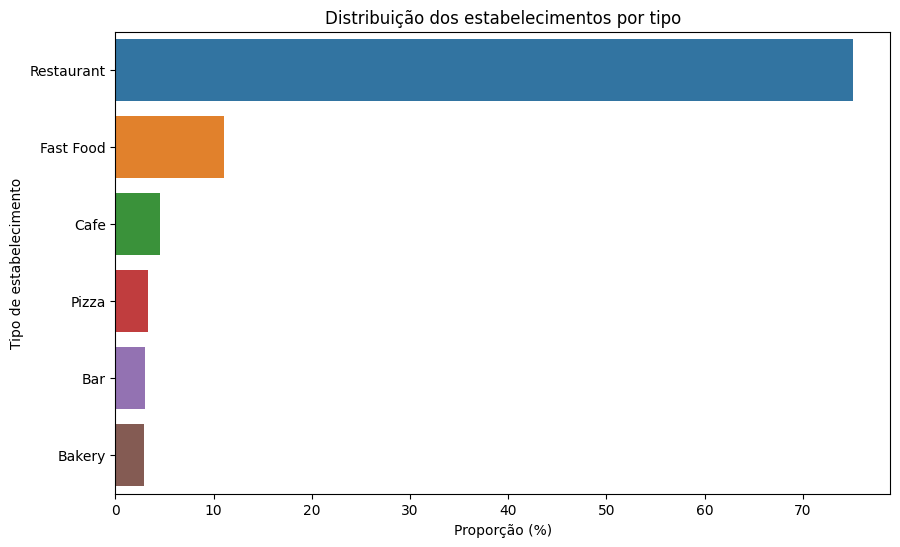

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=type_share.values,
    y=type_share.index
)

plt.title('Distribuição dos estabelecimentos por tipo')
plt.xlabel('Proporção (%)')
plt.ylabel('Tipo de estabelecimento')

plt.show()

### 2.1.3 Interpretação da distribuição dos estabelecimentos por tipo

O mercado analisado é fortemente concentrado em estabelecimentos classificados como **Restaurant**, que representam aproximadamente **75,2%** de todos os estabelecimentos da base.

O segundo tipo mais comum é **Fast Food**, com aproximadamente **11,0%**. As demais categorias apresentam participações significativamente menores: **Cafe** representa cerca de **4,5%**, seguida por **Pizza** (3,3%), **Bar** (3,0%) e **Bakery** (2,9%).

As cafeterias representam uma parcela relativamente pequena do mercado analisado. Isso significa que o segmento possui uma presença menor do que restaurantes e fast food, mas essa participação, por si só, não permite concluir se existe uma oportunidade de negócio. Para avaliar a viabilidade de uma nova cafeteria, será necessário analisar outras características do mercado, como a presença de redes e a capacidade dos estabelecimentos.

### 2.2 Estabelecimentos de rede e independentes

O próximo passo é analisar a proporção de estabelecimentos que pertencem a uma rede em comparação com os estabelecimentos independentes.

Essa análise é importante para compreender o nível de presença de redes no mercado de Los Angeles e avaliar se modelos de negócio que podem ser replicados em diferentes locais já possuem uma participação relevante no mercado.

In [19]:
chain_counts = rest_data['chain'].value_counts()

chain_counts

False    5975
True     3675
Name: chain, dtype: int64

### 2.2.1 Cálculo da proporção de estabelecimentos de rede e independentes

Agora que conhecemos a quantidade de estabelecimentos em cada grupo, vamos calcular a participação percentual dos estabelecimentos de rede e dos estabelecimentos independentes em relação ao total da base.

Essas proporções permitirão comparar o peso de cada modelo de negócio no mercado analisado.

In [20]:
chain_share = rest_data['chain'].value_counts(normalize=True) * 100

chain_share

False    61.917098
True     38.082902
Name: chain, dtype: float64

### 2.2.2 Visualização da proporção de estabelecimentos de rede e independentes

Para visualizar a participação de cada modelo de negócio, vamos construir um gráfico de barras com as proporções calculadas.

O gráfico permitirá comparar diretamente a participação dos estabelecimentos independentes com a participação das redes no mercado analisado.

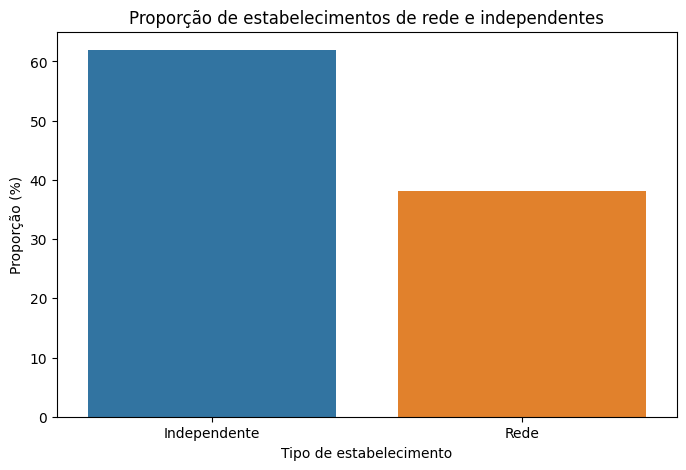

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=chain_share.index,
    y=chain_share.values
)

plt.title('Proporção de estabelecimentos de rede e independentes')
plt.xlabel('Tipo de estabelecimento')
plt.ylabel('Proporção (%)')
plt.xticks([0, 1], ['Independente', 'Rede'])

plt.show()

### 2.2.3 Interpretação da proporção de estabelecimentos de rede e independentes

Os estabelecimentos independentes representam aproximadamente **61,9%** do mercado analisado, enquanto os estabelecimentos pertencentes a redes representam cerca de **38,1%**.

Isso mostra que os negócios independentes são maioria em Los Angeles, mas a participação das redes também é significativa. Portanto, existe uma presença relevante de modelos de negócio que operam em mais de uma unidade.

Para o projeto da cafeteria com garçons robôs, esse resultado é positivo do ponto de vista da possibilidade de expansão, mas ainda não é suficiente para concluir que uma cafeteria seria adequada para operar como rede. Para avaliar essa possibilidade, precisamos investigar quais tipos de estabelecimentos são mais comuns entre as redes.

### 2.3 Tipo de estabelecimento mais comum entre as redes

Agora vamos investigar quais tipos de estabelecimentos apresentam maior presença entre os negócios pertencentes a redes.

Essa análise permitirá identificar qual formato de estabelecimento é mais frequentemente associado a um modelo de negócio em rede e verificar como as cafeterias se posicionam em comparação com os demais tipos.

In [22]:
chain_by_type = rest_data[rest_data['chain'] == True]['object_type'].value_counts()

chain_by_type

Restaurant    2291
Fast Food      605
Bakery         283
Cafe           266
Pizza          153
Bar             77
Name: object_type, dtype: int64

### 2.3.1 Proporção de redes dentro de cada tipo de estabelecimento

A quantidade absoluta de estabelecimentos de rede é influenciada pelo tamanho de cada categoria. Como `Restaurant` é muito mais numeroso na base, precisamos comparar as categorias de forma proporcional.

Para isso, vamos calcular, dentro de cada tipo de estabelecimento, qual percentual pertence a uma rede. Essa comparação permitirá identificar quais tipos são mais característicos de modelos de negócio em rede.

In [23]:
chain_type_share = rest_data.groupby('object_type')['chain'].mean() * 100

chain_type_share.sort_values(ascending=False)

object_type
Bakery        100.000000
Cafe           61.149425
Fast Food      56.754221
Pizza          47.812500
Restaurant     31.582575
Bar            26.369863
Name: chain, dtype: float64

### 2.3.2 Visualização da proporção de redes por tipo de estabelecimento

Para comparar a presença de redes dentro de cada tipo de estabelecimento, vamos construir um gráfico de barras horizontais com os percentuais calculados.

Essa visualização permitirá identificar rapidamente quais categorias apresentam maior proporção de estabelecimentos pertencentes a redes.

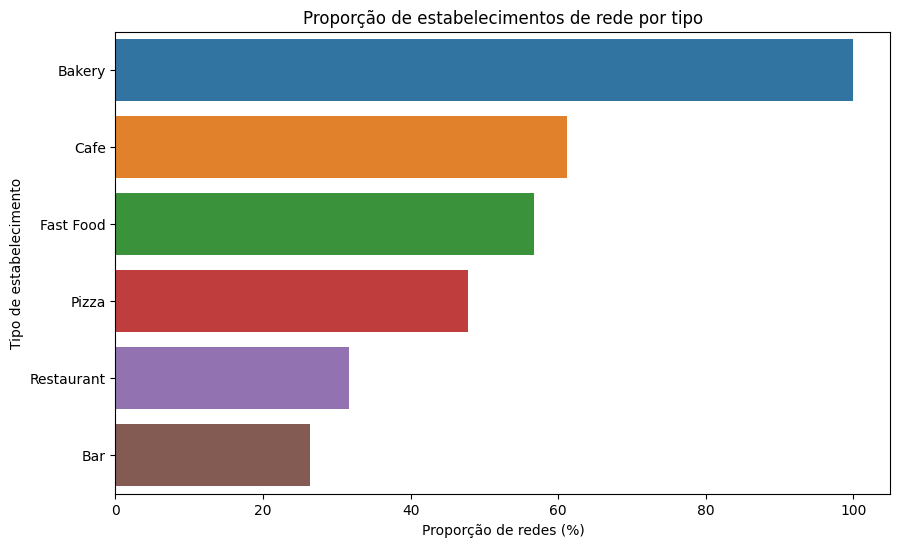

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=chain_type_share.sort_values(ascending=False).values,
    y=chain_type_share.sort_values(ascending=False).index
)

plt.title('Proporção de estabelecimentos de rede por tipo')
plt.xlabel('Proporção de redes (%)')
plt.ylabel('Tipo de estabelecimento')

plt.show()

### 2.3.3 Interpretação: qual tipo de estabelecimento é típico para redes?

A proporção de estabelecimentos pertencentes a redes varia bastante entre os diferentes tipos.

O tipo **Bakery** apresenta a maior proporção de estabelecimentos de rede, com **100%** dos registros classificados como redes. Em seguida aparecem **Cafe**, com **61,1%**, e **Fast Food**, com **56,8%**.

Já **Pizza** apresenta 47,8% de estabelecimentos de rede, enquanto **Restaurant** e **Bar** apresentam proporções menores, de 31,6% e 26,4%, respectivamente.

Esse resultado mostra que o modelo de rede é particularmente comum entre **Bakery, Cafe e Fast Food**. Para o projeto, o dado mais relevante é que **Cafe ocupa a segunda posição**, com mais de 60% dos estabelecimentos pertencendo a redes. Isso indica que o formato de cafeteria pode ser compatível com um modelo de negócio replicável.

No entanto, a categoria Bakery possui 100% de estabelecimentos de rede, mas é uma categoria relativamente pequena na base. Por isso, não devemos considerar apenas a proporção: nas próximas análises, vamos observar também outras características das redes, como a quantidade de unidades e o número de assentos.

### 2.4 Características dos estabelecimentos de rede

Agora vamos investigar as características dos estabelecimentos que pertencem a redes.

O objetivo é verificar se as redes tendem a operar com muitas unidades menores ou com poucas unidades de maior capacidade. Para isso, primeiro vamos identificar quantos estabelecimentos existem para cada rede presente na base.

In [25]:
chain_counts_by_name = (
    rest_data[rest_data['chain'] == True]
    .groupby('object_name')
    .size()
    .sort_values(ascending=False)
)

chain_counts_by_name.head(10)

object_name
THE COFFEE BEAN & TEA LEAF    47
SUBWAY                        31
DOMINO'S PIZZA                15
WABA GRILL                    14
KENTUCKY FRIED CHICKEN        14
MCDONALD'S                    13
TRIMANA                       13
STARBUCKS                     12
PAPA JOHN'S PIZZA             12
YOGURTLAND                    12
dtype: int64

### 2.4.1 Relação entre o número de unidades e o número de assentos

Para entender o que caracteriza os estabelecimentos de rede, vamos comparar o número de unidades de cada rede com o número médio de assentos de seus estabelecimentos.

Se as redes com muitas unidades apresentarem, em geral, poucos assentos por estabelecimento, teremos evidências de que as redes tendem a operar com unidades menores e mais numerosas. Por outro lado, se redes com poucas unidades apresentarem muitos assentos, isso indicará uma estratégia baseada em estabelecimentos maiores e menos numerosos.

In [26]:
chain_summary = (
    rest_data[rest_data['chain'] == True]
    .groupby('object_name')
    .agg(
        number_of_locations=('object_name', 'size'),
        average_seats=('number', 'mean')
    )
    .sort_values('number_of_locations', ascending=False)
)

chain_summary.head(10)

,number_of_locations,average_seats
object_name,,
THE COFFEE BEAN & TEA LEAF,47,26.723404
SUBWAY,31,16.419355
DOMINO'S PIZZA,15,12.333333
WABA GRILL,14,42.857143
KENTUCKY FRIED CHICKEN,14,33.357143
MCDONALD'S,13,96.846154
TRIMANA,13,43.461538
STARBUCKS,12,18.000000
PAPA JOHN'S PIZZA,12,14.500000


### 2.4.2 Visualização da relação entre número de unidades e número de assentos

Para identificar o padrão geral entre as redes, vamos construir um gráfico de dispersão utilizando todas as redes presentes na base.

No eixo horizontal estará o número de unidades de cada rede e, no eixo vertical, o número médio de assentos por estabelecimento.

Essa visualização permitirá observar se existe uma tendência de redes com muitas unidades apresentarem estabelecimentos menores ou se redes com poucas unidades tendem a possuir estabelecimentos com maior capacidade.

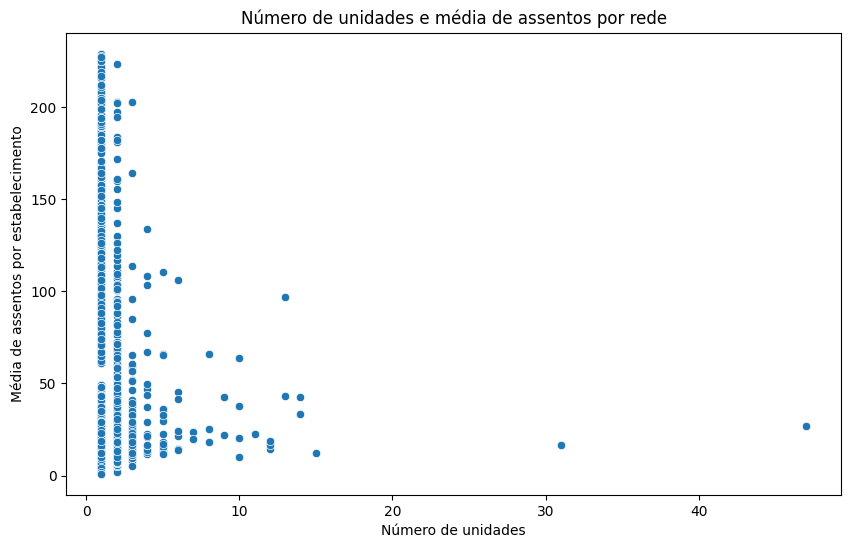

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=chain_summary,
    x='number_of_locations',
    y='average_seats'
)

plt.title('Número de unidades e média de assentos por rede')
plt.xlabel('Número de unidades')
plt.ylabel('Média de assentos por estabelecimento')

plt.show()

### 2.4.3 Interpretação das características dos estabelecimentos de rede

O gráfico mostra que a maior parte das redes possui poucas unidades, enquanto um número menor de redes apresenta muitas unidades.

Também é possível observar uma tendência de redução da média de assentos à medida que aumenta o número de unidades da rede. As redes com maior quantidade de estabelecimentos, como THE COFFEE BEAN & TEA LEAF e SUBWAY, apresentam médias relativamente baixas de assentos por unidade.

Existem algumas exceções, como redes com um número intermediário de unidades e estabelecimentos de maior capacidade. Portanto, não existe uma relação perfeita entre quantidade de unidades e número de assentos, mas o padrão geral indica que as redes tendem a crescer por meio de **um número maior de unidades com capacidade relativamente menor**, em vez de depender de poucas unidades muito grandes.

Esse padrão é relevante para o projeto da cafeteria, pois sugere que um conceito que possa ser reproduzido em unidades de tamanho moderado pode ser compatível com uma estratégia de expansão em rede.

### 2.5 Número médio de assentos por tipo de estabelecimento

Agora vamos analisar a capacidade dos diferentes tipos de estabelecimentos.

Vamos calcular o número médio de assentos para cada categoria de estabelecimento e comparar os resultados. Essa análise ajudará a identificar quais formatos operam, em média, com maior capacidade e servirá como referência para definir um número adequado de assentos para a nova cafeteria.

In [28]:
average_seats_by_type = (
    rest_data.groupby('object_type')['number']
    .mean()
    .sort_values(ascending=False)
)

average_seats_by_type

object_type
Restaurant    48.046044
Bar           44.767123
Fast Food     31.837711
Pizza         28.459375
Cafe          25.000000
Bakery        21.773852
Name: number, dtype: float64

### 2.5.1 Visualização do número médio de assentos por tipo

Para comparar a capacidade média dos diferentes tipos de estabelecimentos, vamos construir um gráfico de barras com o número médio de assentos de cada categoria.

A ordenação dos valores permitirá identificar rapidamente quais tipos de estabelecimentos possuem maior e menor capacidade média.

,average_seats,median_seats
object_type,,
Bakery,21.773852,18.0
Bar,44.767123,28.5
Cafe,25.000000,21.0
Fast Food,31.837711,21.0
Pizza,28.459375,18.5
Restaurant,48.046044,29.0


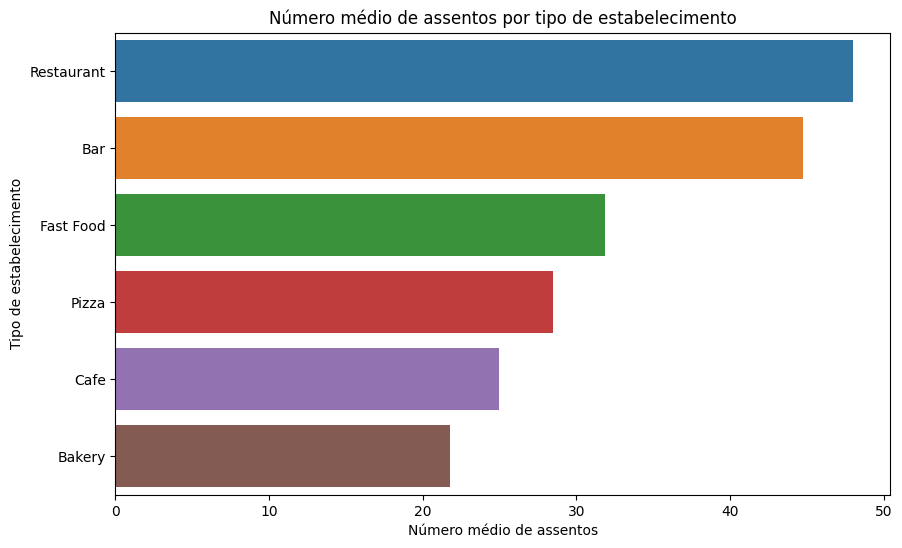

In [29]:
# Calculando a média e a mediana do número de assentos por tipo de estabelecimento
average_seats_by_type = rest_data.groupby('object_type')['number'].mean().sort_values(ascending=False)

median_seats_by_type = rest_data.groupby('object_type')['number'].median()

# Criando uma tabela com média e mediana
seats_by_type = pd.DataFrame({
    'average_seats': average_seats_by_type,
    'median_seats': median_seats_by_type
})

display(seats_by_type)

# Visualização do número médio de assentos por tipo
plt.figure(figsize=(10, 6))

sns.barplot(
    x=average_seats_by_type.values,
    y=average_seats_by_type.index
)

plt.title('Número médio de assentos por tipo de estabelecimento')
plt.xlabel('Número médio de assentos')
plt.ylabel('Tipo de estabelecimento')

plt.show()

### 2.5.2 Interpretação do número médio e mediano de assentos por tipo

A média de assentos varia consideravelmente entre os diferentes tipos de estabelecimentos.

Os estabelecimentos classificados como **Restaurant** apresentam a maior capacidade média, com aproximadamente **48 assentos** por estabelecimento. Os **Bars** apresentam uma média próxima, de aproximadamente **45 assentos**.

Os estabelecimentos de **Fast Food** possuem, em média, cerca de **32 assentos**, enquanto **Pizza** apresenta aproximadamente **28 assentos**.

As **Cafes** possuem uma média de **25 assentos**, enquanto as **Bakery** apresentam a menor capacidade média, com aproximadamente **22 assentos**.

Ao comparar a média com a mediana, observamos diferenças importantes entre as categorias. Nas **Cafes**, por exemplo, a mediana é de **21 assentos**, abaixo da média de **25 assentos**. Isso indica que alguns estabelecimentos com capacidades maiores elevam a média da categoria.

Para a proposta da nova cafeteria, esses resultados mostram que **21 assentos representa melhor o estabelecimento típico**, enquanto a média de **25 assentos** é influenciada por cafeterias maiores. Por isso, uma capacidade entre **25 e 30 assentos** continua sendo uma proposta competitiva, mas representa um porte ligeiramente superior ao da cafeteria típica observada na base.

Por isso, vamos analisar também a distribuição do número de assentos, para entender melhor a variação dentro de cada categoria.

### 2.5.3 Distribuição do número de assentos por tipo de estabelecimento

Para complementar a comparação das médias, vamos analisar a distribuição do número de assentos dentro de cada tipo de estabelecimento.

O boxplot permitirá observar a mediana, a dispersão dos valores e a presença de estabelecimentos com capacidades muito diferentes do padrão de cada categoria. Isso ajudará a avaliar se a média representa adequadamente o perfil dos estabelecimentos.

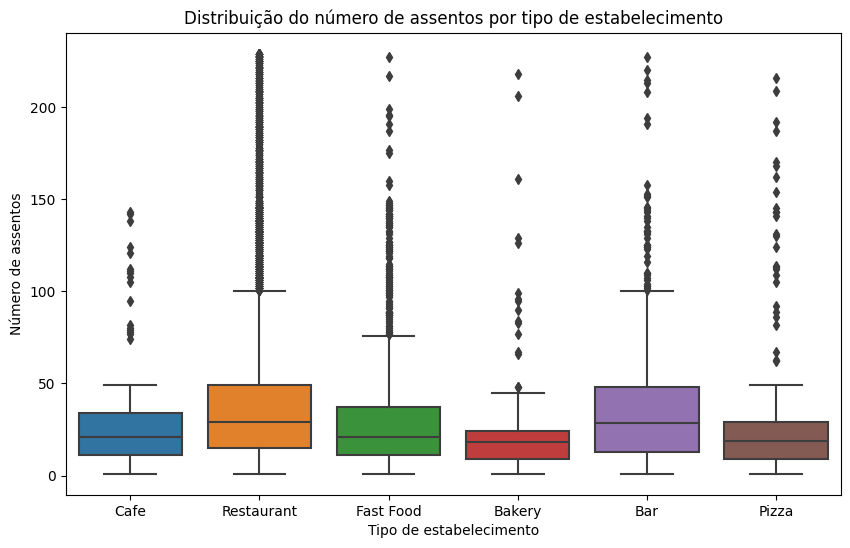

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=rest_data,
    x='object_type',
    y='number'
)

plt.title('Distribuição do número de assentos por tipo de estabelecimento')
plt.xlabel('Tipo de estabelecimento')
plt.ylabel('Número de assentos')

plt.show()

### 2.5.4 Interpretação da distribuição do número de assentos

O boxplot mostra que a distribuição do número de assentos é bastante variável entre os tipos de estabelecimentos.

Os **Restaurants** apresentam a maior capacidade média e também uma dispersão elevada, com muitos estabelecimentos acima do padrão central e diversos valores extremos. Os **Bars** também apresentam uma dispersão relativamente alta.

As **Cafes** apresentam uma distribuição mais concentrada em torno de valores menores de capacidade, embora também existam alguns estabelecimentos com números de assentos muito superiores ao padrão da categoria.

De forma geral, todas as categorias apresentam valores extremos, indicando que existem estabelecimentos muito maiores do que a maioria de seus concorrentes. Por isso, a média deve ser interpretada em conjunto com a distribuição dos dados.

Para a nova cafeteria, os resultados sugerem que uma capacidade próxima ao padrão observado nas cafeterias existentes, em torno de **25 assentos**, seria uma referência mais alinhada ao mercado do que adotar uma capacidade muito elevada.

### 2.6 Extração dos nomes das ruas

Para analisar a distribuição dos restaurantes pelas diferentes ruas de Los Angeles, precisamos separar o nome da rua das demais informações presentes na coluna `address`.

Vamos criar uma nova coluna chamada `street`, contendo o nome da rua extraído de cada endereço. Essa coluna será utilizada nas análises seguintes para identificar as ruas com maior concentração de restaurantes.

In [31]:
rest_data['street'] = rest_data['address'].str.extract(r'^\d+\s+(.*?)(?:\s+\d+)?$')

### 2.6.1 Verificação da nova coluna `street`

Após extrair os nomes das ruas, vamos visualizar alguns endereços junto com os valores obtidos na nova coluna `street`.

Essa verificação permite confirmar se a extração foi realizada corretamente antes de utilizarmos essa informação para contar os restaurantes por rua.

In [32]:
rest_data[['address', 'street']].head(10)

,address,street
0,3708 N EAGLE ROCK BLVD,N EAGLE ROCK BLVD
1,100 WORLD WAY 120,WORLD WAY
2,6801 HOLLYWOOD BLVD 253,HOLLYWOOD BLVD
3,1814 W SUNSET BLVD,W SUNSET BLVD
4,2100 ECHO PARK AVE,ECHO PARK AVE
5,10004 NATIONAL BLVD,NATIONAL BLVD
6,100 WORLD WAY 126,WORLD WAY
7,3500 W 6TH ST STE 226,W 6TH ST STE
8,3027 N SAN FERNANDO RD UNIT 103,N SAN FERNANDO RD UNIT
9,3707 N CAHUENGA BLVD,N CAHUENGA BLVD


### 2.6.2 Ajuste da extração dos nomes das ruas

A primeira extração mostrou que alguns endereços possuem informações adicionais após o nome da rua, como números de unidades, suítes ou outros complementos.

Essas informações não fazem parte do nome da rua e podem fazer com que diferentes registros da mesma rua sejam contados separadamente.

Para evitar esse problema, vamos ajustar a extração para capturar o nome da rua apenas até o seu tipo de via, como `BLVD`, `ST`, `AVE`, `RD`, `WAY`, `DR`, `PL`, `LN`, `CT`, `HWY`, `TER`, `CIR` ou `PKWY`.

Dessa forma, qualquer informação adicional que apareça após o tipo de via será descartada, permitindo agrupar corretamente os estabelecimentos pertencentes à mesma rua.

In [33]:
rest_data['street'] = rest_data['address'].str.extract(
    r'^\d+\s+(.*?\b(?:BLVD|ST|AVE|RD|WAY|DR|PL|LN|CT|HWY|TER|CIR|PKWY)\b)'
)

### 2.6.3 Verificação da extração corrigida

Após ajustar a regra de extração, vamos verificar novamente os endereços e os respectivos nomes das ruas.

Essa etapa permite confirmar se o nome da rua foi mantido corretamente e se informações adicionais presentes após o tipo de via foram removidas.

In [34]:
rest_data[['address', 'street']].head(10)

,address,street
0,3708 N EAGLE ROCK BLVD,N EAGLE ROCK BLVD
1,100 WORLD WAY 120,WORLD WAY
2,6801 HOLLYWOOD BLVD 253,HOLLYWOOD BLVD
3,1814 W SUNSET BLVD,W SUNSET BLVD
4,2100 ECHO PARK AVE,ECHO PARK AVE
5,10004 NATIONAL BLVD,NATIONAL BLVD
6,100 WORLD WAY 126,WORLD WAY
7,3500 W 6TH ST STE 226,W 6TH ST
8,3027 N SAN FERNANDO RD UNIT 103,N SAN FERNANDO RD
9,3707 N CAHUENGA BLVD,N CAHUENGA BLVD


In [35]:
print(rest_data['street'].nunique())

ruas = rest_data['street'].value_counts()

print(
    ruas[
        ruas.index.str.contains(
            r'\b(?:STE|UNIT|SPC|BLDG|FL)\b|#',
            regex=True,
            na=False
        )
    ]
)

775
N GOWER  BLDG 10 ST    1
Name: street, dtype: int64


In [36]:
rest_data.loc[
    rest_data['street'].str.contains('GOWER', na=False),
    ['address', 'street']
]

,address,street
415,1514 N GOWER ST,N GOWER ST
1655,1438 N GOWER BLDG 10 ST BOX 56,N GOWER BLDG 10 ST
5404,1149 N GOWER ST,N GOWER ST
9429,1149 N GOWER ST,N GOWER ST


### 2.6.4 Conclusão da extração dos nomes das ruas

A extração dos nomes das ruas foi verificada após o ajuste da expressão regular. A nova regra reduziu o número de nomes distintos para **775 ruas** e removeu corretamente informações adicionais, como números de unidades e suítes, na maioria dos endereços.

Durante a verificação, foi identificado um caso isolado em que a informação **`BLDG 10`** aparece no meio do nome extraído:

1438 N GOWER BLDG 10 ST BOX 56 → N GOWER BLDG 10 ST

Como esse complemento aparece antes do tipo de via (`ST`), ele não é removido pela regra atual. No entanto, trata-se de um caso pontual e a extração está adequada para a análise da distribuição dos estabelecimentos por rua.

Com a coluna `street` preparada e verificada, podemos seguir para a análise das ruas com maior concentração de estabelecimentos.

## 2.7 Número de restaurantes por rua

Com os nomes das ruas extraídos e organizados na coluna `street`, podemos analisar a concentração de estabelecimentos em diferentes partes da cidade.

Primeiro, vamos contar quantos estabelecimentos estão localizados em cada rua. Em seguida, utilizaremos esses resultados para identificar as dez ruas com maior número de estabelecimentos.

In [37]:
street_counts = rest_data['street'].value_counts()

street_counts.head(10)

WILSHIRE BLVD        381
W SUNSET BLVD        360
W PICO BLVD          340
S WESTERN AVE        271
SANTA MONICA BLVD    262
HOLLYWOOD BLVD       241
W OLYMPIC BLVD       231
S FIGUEROA ST        227
W 3RD ST             225
W 6TH ST             212
Name: street, dtype: int64

### 2.7.1 Visualização das dez ruas com maior número de restaurantes

Agora vamos visualizar as dez ruas que concentram o maior número de estabelecimentos na base.

Um gráfico de barras horizontais é adequado para esse ranking, pois permite comparar diretamente a quantidade de estabelecimentos e facilita a leitura dos nomes das ruas.

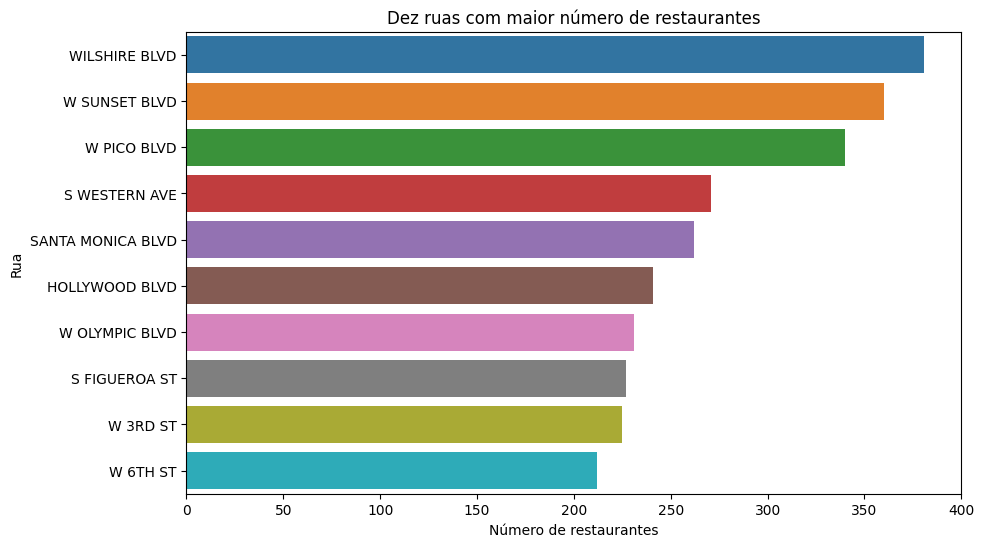

In [38]:
top_10_streets = street_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_streets.values,
    y=top_10_streets.index
)

plt.title('Dez ruas com maior número de restaurantes')
plt.xlabel('Número de restaurantes')
plt.ylabel('Rua')

plt.show()

### 2.7.2 Interpretação das dez ruas com maior número de restaurantes

A distribuição dos estabelecimentos pelas ruas apresenta uma concentração significativa em algumas áreas da cidade.

As ruas com maior número de estabelecimentos são **WILSHIRE BLVD**, com **381 estabelecimentos**, e **W SUNSET BLVD**, com **360 estabelecimentos**.

Em seguida aparecem **W PICO BLVD**, com **340**, **S WESTERN AVE**, com **271**, e **SANTA MONICA BLVD**, com **262**.

As demais ruas entre as dez primeiras apresentam entre **212 e 241 estabelecimentos**, mostrando que existe uma concentração relevante de restaurantes em determinadas vias.

Essa concentração pode ser importante para a escolha da localização de uma nova cafeteria. Ruas com muitos estabelecimentos podem indicar maior fluxo de pessoas e potencial demanda, mas também podem representar maior concorrência. Portanto, a escolha da localização deve considerar outros fatores além da quantidade de restaurantes presentes na região.

### 2.8 Ruas com apenas um restaurante

Além das ruas com alta concentração de estabelecimentos, também é importante identificar quantas ruas possuem apenas um restaurante na base.

Essa informação ajudará a compreender se os estabelecimentos estão concentrados em determinadas ruas ou se existe uma grande quantidade de ruas com baixa presença de restaurantes.

In [39]:
streets_with_one_restaurant = (street_counts == 1).sum()

streets_with_one_restaurant

340

### 2.8.1 Interpretação das ruas com apenas um restaurante

Foram identificadas **340 ruas com apenas um restaurante** na base analisada.

Esse resultado mostra que, embora algumas ruas concentrem um grande número de estabelecimentos, também existem ruas com baixa presença de restaurantes.

Essa distribuição reforça que os restaurantes não estão distribuídos de forma uniforme pela cidade. Para a escolha da localização de uma nova cafeteria, áreas com poucos restaurantes podem representar menor concorrência, mas também é importante considerar outros fatores, como o fluxo de pessoas e a demanda da região.

### 2.9 Distribuição do número de assentos nas ruas com muitos restaurantes

Na etapa anterior, identificamos as dez ruas com maior número de restaurantes. Agora vamos analisar como o número de assentos está distribuído nos estabelecimentos localizados nessas ruas.

Essa análise permitirá verificar se as áreas com maior concentração de restaurantes são ocupadas principalmente por estabelecimentos pequenos, médios ou grandes, e identificar possíveis padrões que possam ajudar na escolha da localização e da capacidade da nova cafeteria.

In [40]:
top_10_streets = street_counts.head(10)

top_10_streets

WILSHIRE BLVD        381
W SUNSET BLVD        360
W PICO BLVD          340
S WESTERN AVE        271
SANTA MONICA BLVD    262
HOLLYWOOD BLVD       241
W OLYMPIC BLVD       231
S FIGUEROA ST        227
W 3RD ST             225
W 6TH ST             212
Name: street, dtype: int64

In [41]:
top_10_streets_data = rest_data[
    rest_data['street'].isin(top_10_streets.index)
]

top_10_streets_data[['street', 'number']].head()

,street,number
2,HOLLYWOOD BLVD,20
3,W SUNSET BLVD,22
7,W 6TH ST,7
10,W SUNSET BLVD,38
11,S WESTERN AVE,17


### 2.9.1 Visualização da distribuição de assentos nas ruas mais movimentadas

Para comparar a distribuição do número de assentos nas dez ruas com maior concentração de restaurantes, vamos utilizar um boxplot.

O gráfico permitirá comparar a mediana, a dispersão e os valores extremos de assentos entre as diferentes ruas, ajudando a identificar possíveis padrões nas áreas com maior concentração de estabelecimentos.

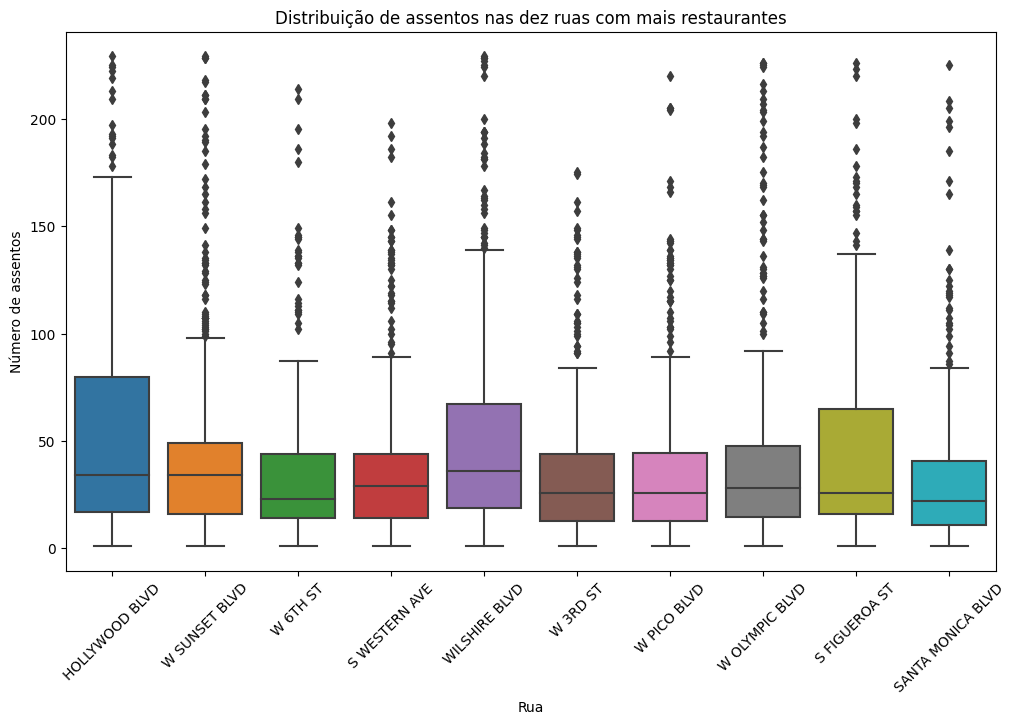

In [42]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=top_10_streets_data,
    x='street',
    y='number'
)

plt.title('Distribuição de assentos nas dez ruas com mais restaurantes')
plt.xlabel('Rua')
plt.ylabel('Número de assentos')
plt.xticks(rotation=45)

plt.show()

### 2.9.2 Interpretação da distribuição de assentos nas ruas com muitos restaurantes

Nas dez ruas com maior concentração de restaurantes, a maior parte dos estabelecimentos apresenta uma capacidade relativamente moderada. As medianas variam aproximadamente entre 20 e 35 assentos na maioria das ruas.

Algumas ruas, como WILSHIRE BLVD e S FIGUEROA ST, apresentam maior dispersão na quantidade de assentos, indicando uma variedade maior no tamanho dos estabelecimentos.

Também é possível observar diversos valores extremos em todas as ruas analisadas, com alguns restaurantes ultrapassando 200 assentos. Isso mostra que, mesmo nas áreas com alta concentração de restaurantes, existem estabelecimentos de diferentes tamanhos.

De modo geral, a alta concentração de restaurantes em uma rua não significa necessariamente que predominem estabelecimentos grandes. A maior parte dos negócios apresenta capacidade moderada, enquanto os restaurantes muito grandes representam uma parcela menor da distribuição.

# 3. Conclusões e recomendações

A análise do mercado de restaurantes de Los Angeles mostra que o setor é fortemente dominado por restaurantes tradicionais, que representam aproximadamente **75,2%** da base. Os estabelecimentos independentes são maioria, correspondendo a **61,9%**, enquanto as redes representam **38,1%**.

Apesar de as cafeterias representarem apenas **4,5%** dos estabelecimentos analisados, o formato apresenta uma característica relevante para o projeto: aproximadamente **61,1% das cafeterias pertencem a redes**. Isso indica que o modelo de cafeteria pode ser adequado para uma estratégia de expansão e replicação em diferentes locais.

Em relação à capacidade, as cafeterias possuem, em média, **25 assentos**, e a distribuição observada mostra que a maioria dos estabelecimentos desse tipo opera com uma capacidade relativamente moderada. Por isso, recomenda-se iniciar o projeto com uma cafeteria de aproximadamente **25 a 30 assentos**, mantendo uma estrutura que permita testar a demanda sem exigir um espaço excessivamente grande.

A análise das redes também indica que modelos com maior número de unidades tendem a operar com estabelecimentos de capacidade relativamente menor. Isso favorece uma estratégia baseada em unidades compactas e replicáveis, em vez de grandes estabelecimentos.

Quanto à localização, a distribuição dos restaurantes não é uniforme. Enquanto algumas ruas concentram centenas de estabelecimentos, após a padronização dos nomes foram identificadas **340 ruas com apenas um restaurante**. As dez ruas com maior concentração de restaurantes também apresentam grande variedade no número de assentos, embora a maior parte dos estabelecimentos possua capacidade moderada. Portanto, a escolha da localização deve equilibrar o potencial de fluxo de clientes e demanda da região com o nível de concorrência existente.

## Recomendação final

Com base nos resultados, o formato mais adequado para o projeto é uma **cafeteria de tamanho moderado, com aproximadamente 25 a 30 assentos**, localizada em uma região com potencial de fluxo de clientes e demanda, sem necessariamente escolher a área com a maior concentração de restaurantes.

O modelo também apresenta **potencial para desenvolvimento como rede**. A elevada proporção de cafeterias pertencentes a redes e o padrão observado nas unidades compactas indicam que estabelecimentos de tamanho moderado podem ser replicados em diferentes localizações.

A utilização de garçons robôs pode funcionar como um diferencial para atrair clientes e fortalecer a identidade da marca. No entanto, a viabilidade do negócio no longo prazo dependerá principalmente da capacidade de manter uma boa experiência para o cliente, mesmo após o efeito inicial da novidade tecnológica diminuir.

### Apresentação
LINK: https://docs.google.com/presentation/d/1lwua3yKXKlHG7IbE78_nldM6EGLWl8nz9H-bN0g69go/edit?usp=sharing